# TabPFN Approach

This notebook applies the pre-trained TabPFN model to estimate the probability of borrower default using the Lending Club dataset.



In [1]:
## Base library Installatio
# Install rich for better and more readable printing
!uv pip install rich

## TabPFN Installation optimized for Google Colab
# Install the TabPFN Client library
!uv pip install tabpfn-client

# Install TabPFN extensions for additional functionalities
!uv pip install 'tabpfn-extensions[all]'

# Install tabpfn
!uv pip install tabpfn

Using Python 3.12.12 environment at: /usr
Audited 1 package in 210ms
Using Python 3.12.12 environment at: /usr
Resolved 33 packages in 567ms
Prepared 5 packages in 41ms
Uninstalled 1 package in 3ms
Installed 5 packages in 6ms
 + backoff==2.2.1
 + password-strength==0.0.3.post2
 + sseclient-py==1.8.0
 + tabpfn-client==0.2.8
 - tqdm==4.67.3
 + tqdm==4.67.1
Using Python 3.12.12 environment at: /usr
Resolved 111 packages in 1.25s
Prepared 19 packages in 537ms
Uninstalled 1 package in 1ms
Installed 19 packages in 75ms
 + autogluon-common==1.4.0
 + autogluon-core==1.4.0
 + autogluon-features==1.4.0
 + autogluon-tabular==1.4.0
 + boto3==1.42.63
 + botocore==1.42.63
 + ecos==2.0.14
 + eval-type-backport==0.3.1
 + galois==0.4.10
 + jmespath==1.1.0
 + posthog==6.9.3
 - requests==2.32.4
 + requests==2.32.5
 + s3transfer==0.16.0
 + scikit-survival==0.26.0
 + shapiq==1.4.1
 + sparse-transform==0.2.1
 + tabpfn==6.4.1
 + tabpfn-common-utils==0.2.16
 + tabpfn-extensions==0.2.2
Using Python 3.12.12 env

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Simple import for TabPFN
from tabpfn_client import TabPFNClassifier

from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

from tabpfn import TabPFNClassifier
from tabpfn.finetuning.finetuned_classifier import (
    FinetunedTabPFNClassifier,
)

In [3]:
from google.colab import files
uploaded = files.upload()
# df_imp_clean = pd.read_csv("df_imp_clean.csv")

Saving df_imp_clean.csv to df_imp_clean.csv
Saving lendingclub_sample_50k.csv to lendingclub_sample_50k.csv


In [ ]:
df = pd.read_csv("lendingclub_sample_50k.csv")

# Data cleaning

In [ ]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,has_delinq,loan_status_binary
0,30000,36 months,9.99,967.88,B,B3,10+ years,RENT,120000.0,Source Verified,...,71.4,0.0,0.0,60550.0,39910.0,45800.0,12050.0,Cash,0,0
1,10000,36 months,14.08,342.17,C,C3,5 years,RENT,90000.0,Not Verified,...,100.0,0.0,0.0,22852.0,9238.0,5000.0,12452.0,Cash,1,0
2,16000,60 months,16.91,396.87,C,C5,< 1 year,MORTGAGE,145000.0,Source Verified,...,20.0,0.0,0.0,263265.0,65370.0,49400.0,46165.0,Cash,0,0
3,20000,36 months,10.49,649.96,B,B3,10+ years,RENT,150000.0,Verified,...,25.0,0.0,0.0,43553.0,18720.0,22000.0,21553.0,Cash,1,0
4,4500,36 months,7.97,140.96,A,A5,< 1 year,RENT,56000.0,Not Verified,...,0.0,0.0,0.0,52600.0,30614.0,27600.0,25000.0,Cash,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 98 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   loan_amnt                       50000 non-null  int64  
 1   term                            50000 non-null  object 
 2   int_rate                        50000 non-null  float64
 3   installment                     50000 non-null  float64
 4   grade                           50000 non-null  object 
 5   sub_grade                       50000 non-null  object 
 6   emp_length                      46974 non-null  object 
 7   home_ownership                  50000 non-null  object 
 8   annual_inc                      50000 non-null  float64
 9   verification_status             50000 non-null  object 
 10  pymnt_plan                      50000 non-null  object 
 11  purpose                         50000 non-null  object 
 12  zip_code                        

In [ ]:
# This core candidate are the most influential predictors (in a economic context not statistical context) that we should alwyas keep
core_hist = [
    'delinq_2yrs',
    'num_accts_ever_120_pd',
    'num_tl_90g_dpd_24m',
    'mths_since_last_delinq',
    'pub_rec_bankruptcies',
    'tax_liens',
    'mths_since_last_major_derog',
    'pct_tl_nvr_dlq'
]
core_repay = [
    'dti',
    'revol_util',
    'percent_bc_gt_75',
    'bc_util',
    'all_util',
    'installment',
    'loan_amnt',
    'annual_inc',
    'avg_cur_bal',
    'total_bal_ex_mort',
    'tot_cur_bal'
]
core_stability = [
    'earliest_cr_line',
    'mo_sin_old_rev_tl_op',
    'total_acc',
    'open_acc'
]
core_riskbehavior = [
    'inq_last_6mths',
    'inq_last_12m',
    'num_tl_op_past_12m',
    'acc_now_delinq',
    'chargeoff_within_12_mths',
    'collections_12_mths_ex_med'
]

sec_candidate = [
    'term',
    'purpose',
    'initial_list_status',
    'num_actv_bc_tl',
    'num_rev_accts',
    'num_il_tl',
    'total_rev_hi_lim',
    'total_bc_limit',
    'total_il_high_credit_limit',
    'max_bal_bc',
    'home_ownership',
    'addr_state',
    'zip_code',
    'emp_length',
    'verification_status'
]


In [ ]:
all_core_cols = core_hist + core_repay + core_stability + core_riskbehavior + sec_candidate

df_core = df[all_core_cols + ['loan_status_binary']]

In [ ]:
df_core.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   delinq_2yrs                  50000 non-null  float64
 1   num_accts_ever_120_pd        48336 non-null  float64
 2   num_tl_90g_dpd_24m           48336 non-null  float64
 3   mths_since_last_delinq       50000 non-null  float64
 4   pub_rec_bankruptcies         49960 non-null  float64
 5   tax_liens                    49995 non-null  float64
 6   mths_since_last_major_derog  50000 non-null  float64
 7   pct_tl_nvr_dlq               48331 non-null  float64
 8   dti                          50000 non-null  float64
 9   revol_util                   49962 non-null  float64
 10  percent_bc_gt_75             48325 non-null  float64
 11  bc_util                      48304 non-null  float64
 12  all_util                     29830 non-null  float64
 13  installment     

In [ ]:
pd.value_counts(df.loan_status_binary).to_frame().reset_index()

/tmp/ipykernel_408/904198908.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df.loan_status_binary).to_frame().reset_index()


,loan_status_binary,count
0,0,43479
1,1,6521


# Missing Value Imputation

In [ ]:
def get_missing_value_stats(input_df):
    df_null = pd.DataFrame({
        'Missing Count': input_df.isnull().sum(),
        'Missing Percent': 100 * input_df.isnull().sum() / len(input_df),
        'Type': input_df.dtypes
    })
    missing_values = df_null[df_null['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
    return missing_values

def get_value_stats(input_df):
    df_null = pd.DataFrame({
        '#Count': input_df.notna().sum(),
        '%Populated': 100 * input_df.notna().sum() / len(input_df),
        '#Unique Values':input_df.nunique(),
        'Most Common Value': input_df.mode().iloc[0],
        'Type': input_df.dtypes
    })

    missing_values = df_null[df_null['#Count'] > 0].sort_values(by='#Count', ascending=False)

    return missing_values

# Finding the the count and percentage of values that are missing.
get_missing_value_stats(df)

,Missing Count,Missing Percent,Type
il_util,24424,48.848,float64
mths_since_rcnt_il,21046,42.092,float64
all_util,20170,40.340,float64
total_cu_tl,20168,40.336,float64
open_acc_6m,20168,40.336,float64
inq_last_12m,20168,40.336,float64
open_il_24m,20167,40.334,float64
open_rv_24m,20167,40.334,float64
open_rv_12m,20167,40.334,float64
total_bal_il,20167,40.334,float64


In [ ]:
import numpy as np

df_imp = df_core.copy()

# ------------------------------
# 1️⃣ High-missing credit activity variables (~40–50%)
# Fill with 0 (structural absence)
# ------------------------------

high_missing_zero_fill = [
    'il_util', 'all_util', 'total_cu_tl',
    'open_acc_6m', 'inq_last_12m',
    'open_il_24m', 'open_rv_24m', 'open_rv_12m',
    'total_bal_il', 'max_bal_bc',
    'inq_fi', 'open_act_il', 'open_il_12m'
]

for col in high_missing_zero_fill:
    if col in df_imp.columns:
        df_imp[col + "_missing"] = df_imp[col].isna().astype(int)
        df_imp[col] = df_imp[col].fillna(0)


# ------------------------------
# 2️⃣ mths_since_* variables
# Missing means event never occurred
# Fill with 999 + indicator
# ------------------------------

mths_since_cols = [
    'mths_since_rcnt_il',
    'mths_since_recent_inq',
    'mths_since_recent_bc',
    'mths_since_recent_revol_delinq'
]

for col in mths_since_cols:
    if col in df_imp.columns:
        df_imp[col + "_missing"] = df_imp[col].isna().astype(int)
        df_imp[col] = df_imp[col].fillna(999)


# ------------------------------
# 3️⃣ Small-missing numeric variables (<5%)
# Fill with median
# ------------------------------

small_missing_numeric = [
    'bc_util', 'percent_bc_gt_75', 'bc_open_to_buy',
    'pct_tl_nvr_dlq', 'avg_cur_bal', 'num_rev_accts',
    'total_il_high_credit_limit', 'tot_hi_cred_lim',
    'num_tl_op_past_12m', 'tot_cur_bal', 'total_rev_hi_lim',
    'tot_coll_amt', 'num_op_rev_tl', 'num_il_tl', 'num_bc_tl',
    'num_actv_bc_tl', 'num_actv_rev_tl',
    'mo_sin_rcnt_tl', 'mo_sin_rcnt_rev_tl_op',
    'num_accts_ever_120_pd', 'mo_sin_old_rev_tl_op',
    'num_tl_90g_dpd_24m', 'num_tl_30dpd',
    'num_rev_tl_bal_gt_0', 'num_bc_sats', 'num_sats',
    'total_bal_ex_mort', 'acc_open_past_24mths',
    'total_bc_limit', 'mort_acc',
    'pub_rec_bankruptcies', 'revol_util',
    'chargeoff_within_12_mths',
    'collections_12_mths_ex_med',
    'tax_liens', 'inq_last_6mths',
    'num_tl_120dpd_2m', 'mo_sin_old_il_acct'
]

for col in small_missing_numeric:
    if col in df_imp.columns:
        median_value = df_imp[col].median()
        df_imp[col] = df_imp[col].fillna(median_value)


# ------------------------------
# 4️⃣ Employment length (categorical)
# ------------------------------

if 'emp_length' in df_imp.columns:
    df_imp['emp_length'] = df_imp['emp_length'].fillna("Unknown")


# ------------------------------
# 5️⃣ Final sanity check
# ------------------------------

print("Remaining missing values:")
get_missing_value_stats(df_imp)

Remaining missing values:


,Missing Count,Missing Percent,Type


# EDA

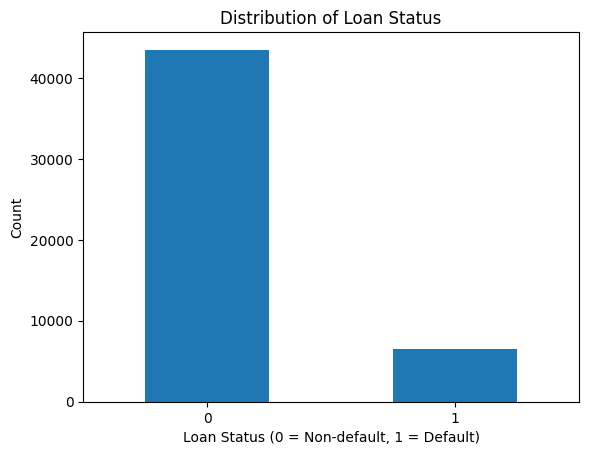

In [ ]:

df_imp['loan_status_binary'].value_counts().sort_index().plot(kind='bar')

plt.xlabel("Loan Status (0 = Non-default, 1 = Default)")
plt.ylabel("Count")
plt.title("Distribution of Loan Status")
plt.xticks(rotation=0)
plt.show()

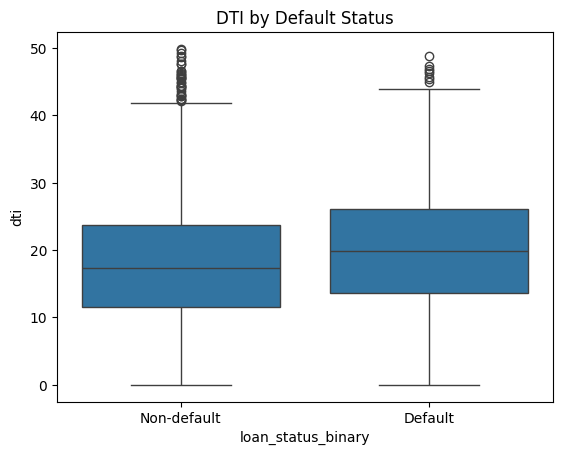

In [ ]:
import seaborn as sns

sns.boxplot(x='loan_status_binary', y='dti', data=df_imp)
plt.xticks([0,1], ['Non-default','Default'])
plt.title("DTI by Default Status")
plt.show()

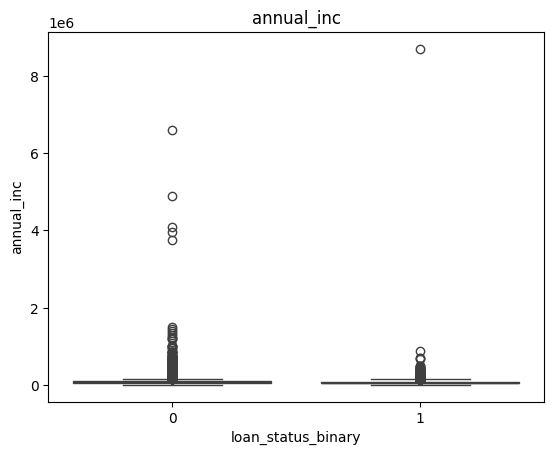

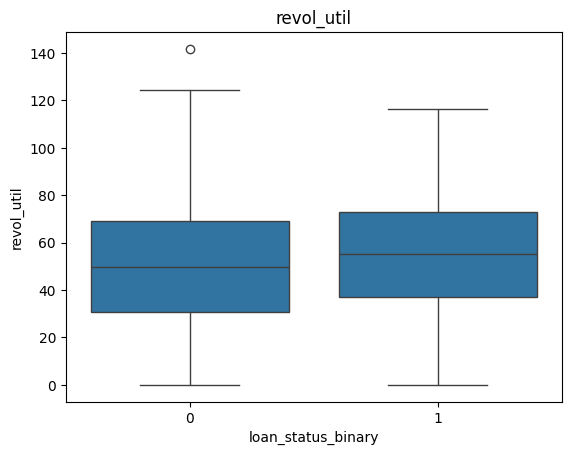

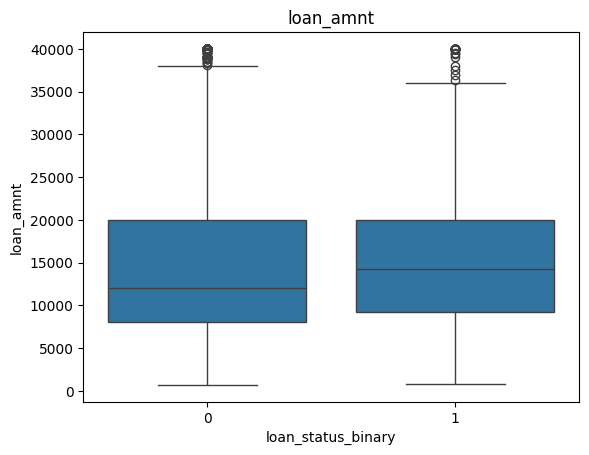

In [ ]:
for col in ['annual_inc','revol_util','loan_amnt']:
    sns.boxplot(x='loan_status_binary', y=col, data=df_imp)
    plt.title(col)
    plt.show()

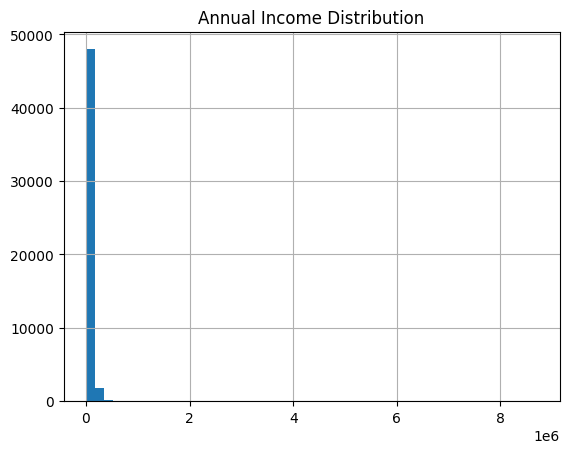

In [ ]:
df_imp['annual_inc'].hist(bins=50)
plt.title("Annual Income Distribution")
plt.show()

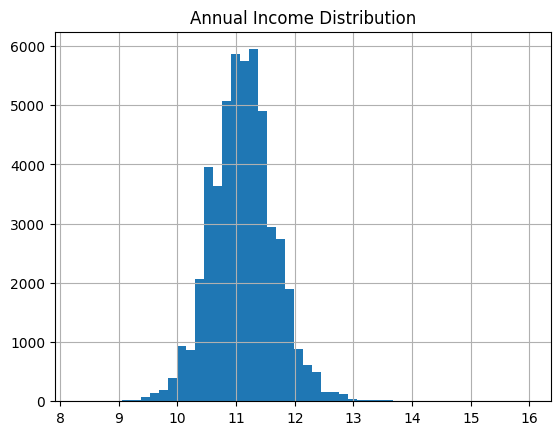

In [ ]:
np.log(df_imp['annual_inc']).hist(bins=50)
plt.title("Annual Income Distribution")
plt.show()

In [ ]:
df_imp['log_annual_inc'] = df_imp['annual_inc'].apply(np.log)

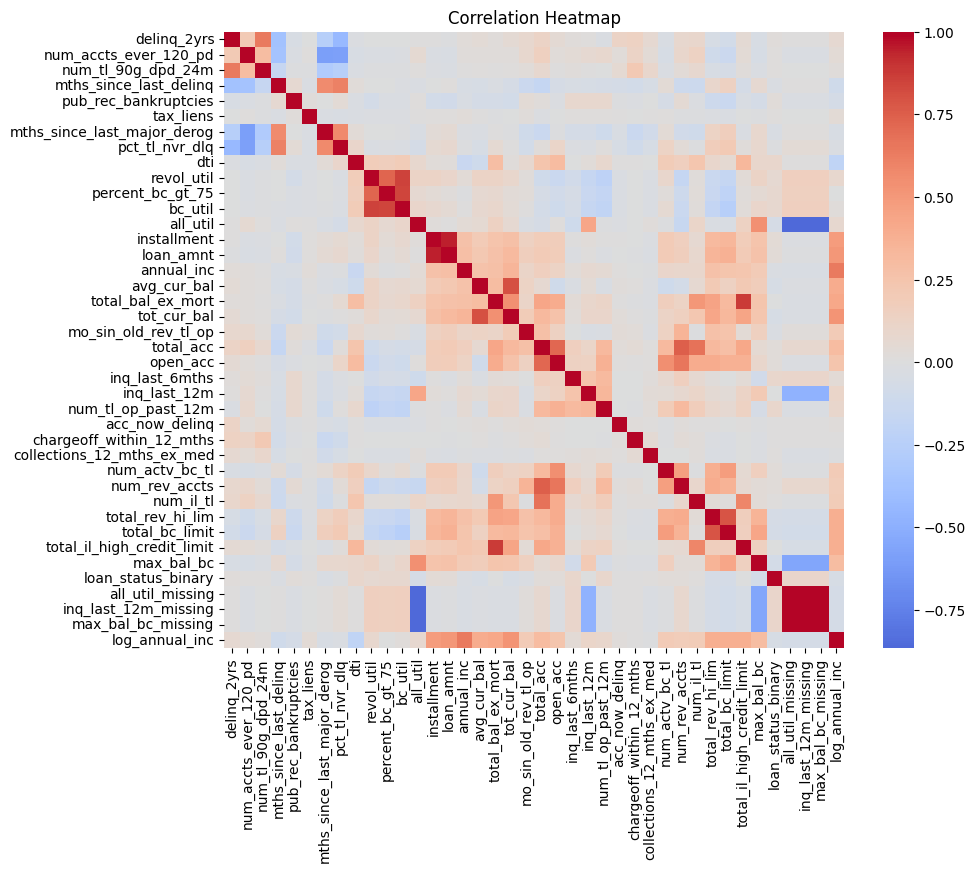

In [ ]:
corr = df_imp.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df_imp.describe()

,delinq_2yrs,num_accts_ever_120_pd,num_tl_90g_dpd_24m,mths_since_last_delinq,pub_rec_bankruptcies,tax_liens,mths_since_last_major_derog,pct_tl_nvr_dlq,dti,revol_util,...,num_il_tl,total_rev_hi_lim,total_bc_limit,total_il_high_credit_limit,max_bal_bc,loan_status_binary,all_util_missing,inq_last_12m_missing,max_bal_bc_missing,log_annual_inc
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.31058,0.499000,0.080300,524.426320,0.126400,0.046200,746.563140,94.162002,18.071969,50.446815,...,8.371100,3.426096e+04,23060.421840,4.309179e+04,3460.571860,0.130420,0.403400,0.403360,0.403340,11.114592
std,0.87408,1.352951,0.479559,482.420783,0.367077,0.344598,421.187291,8.987699,8.423495,24.739381,...,7.270964,3.526509e+04,23343.534864,4.453120e+04,5148.418275,0.336768,0.490585,0.490577,0.490573,0.547587
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,8.294050
25%,0.00000,0.000000,0.000000,32.000000,0.000000,0.000000,77.000000,91.700000,11.720000,31.575000,...,4.000000,1.500000e+04,8500.000000,1.529800e+04,0.000000,0.000000,0.000000,0.000000,0.000000,10.757903
50%,0.00000,0.000000,0.000000,999.000000,0.000000,0.000000,999.000000,98.500000,17.610000,50.300000,...,6.000000,2.550000e+04,16100.000000,3.260250e+04,1595.000000,0.000000,0.000000,0.000000,0.000000,11.082143
75%,0.00000,0.000000,0.000000,999.000000,0.000000,0.000000,999.000000,100.000000,24.000000,69.600000,...,11.000000,4.210000e+04,29700.000000,5.681900e+04,5118.000000,0.000000,1.000000,1.000000,1.000000,11.461632
max,32.00000,28.000000,30.000000,999.000000,8.000000,13.000000,999.000000,100.000000,49.880000,141.800000,...,99.000000,1.641300e+06,834300.000000,1.269783e+06,207220.000000,1.000000,1.000000,1.000000,1.000000,15.979590


# Feature Engineering

In [ ]:
df_imp.columns

Index(['delinq_2yrs', 'num_accts_ever_120_pd', 'num_tl_90g_dpd_24m',
       'mths_since_last_delinq', 'pub_rec_bankruptcies', 'tax_liens',
       'mths_since_last_major_derog', 'pct_tl_nvr_dlq', 'dti', 'revol_util',
       'percent_bc_gt_75', 'bc_util', 'all_util', 'installment', 'loan_amnt',
       'annual_inc', 'avg_cur_bal', 'total_bal_ex_mort', 'tot_cur_bal',
       'earliest_cr_line', 'mo_sin_old_rev_tl_op', 'total_acc', 'open_acc',
       'inq_last_6mths', 'inq_last_12m', 'num_tl_op_past_12m',
       'acc_now_delinq', 'chargeoff_within_12_mths',
       'collections_12_mths_ex_med', 'term', 'purpose', 'initial_list_status',
       'num_actv_bc_tl', 'num_rev_accts', 'num_il_tl', 'total_rev_hi_lim',
       'total_bc_limit', 'total_il_high_credit_limit', 'max_bal_bc',
       'home_ownership', 'addr_state', 'zip_code', 'emp_length',
       'verification_status', 'loan_status_binary', 'all_util_missing',
       'inq_last_12m_missing', 'max_bal_bc_missing'],
      dtype='object')

In [ ]:
cat_cols = df_imp.select_dtypes(include=['object', 'category']).columns
print(cat_cols)

Index(['earliest_cr_line', 'term', 'purpose', 'initial_list_status',
       'home_ownership', 'addr_state', 'zip_code', 'emp_length',
       'verification_status'],
      dtype='object')


In [ ]:
for col in cat_cols:
    print(col, ":", df_imp[col].nunique())

earliest_cr_line : 620
term : 2
purpose : 14
initial_list_status : 2
home_ownership : 6
addr_state : 50
zip_code : 869
emp_length : 12
verification_status : 3


In [ ]:
df_imp['addr_state'].unique()

array(['TX', 'CA', 'FL', 'NY', 'PA', 'IL', 'MA', 'IN', 'VA', 'GA', 'LA',
       'NV', 'ND', 'KS', 'NJ', 'MO', 'AZ', 'DC', 'WA', 'MI', 'MD', 'MS',
       'TN', 'HI', 'NC', 'CT', 'OK', 'SD', 'MN', 'OH', 'NM', 'AR', 'OR',
       'NE', 'SC', 'WI', 'ME', 'WV', 'MT', 'CO', 'DE', 'AL', 'KY', 'AK',
       'VT', 'ID', 'RI', 'NH', 'WY', 'UT'], dtype=object)

In [ ]:
# Map state to region
state_to_region = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast','RI':'Northeast','VT':'Northeast',
    'NJ':'Northeast','NY':'Northeast','PA':'Northeast',

    'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
    'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest','ND':'Midwest','SD':'Midwest',

    'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South','SC':'South','VA':'South','DC':'South','WV':'South',
    'AL':'South','KY':'South','MS':'South','TN':'South',
    'AR':'South','LA':'South','OK':'South','TX':'South',

    'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West','NM':'West','UT':'West','WY':'West',
    'AK':'West','CA':'West','HI':'West','OR':'West','WA':'West'
}

df_imp['region'] = df_imp['addr_state'].map(state_to_region)

In [ ]:
# df_imp["zip_code"].unique()
df_imp['zip_region'] = df_imp['zip_code'].str[0].astype(int)

In [ ]:
df_imp['zip_region'].unique()

array([7, 9, 3, 1, 6, 0, 4, 2, 8, 5])

In [ ]:
purpose_map = {
    'credit_card': 'debt',
    'debt_consolidation': 'debt',

    'home_improvement': 'home_investment',
    'house': 'home_investment',
    'renewable_energy': 'home_investment',

    'car': 'major_purchase',
    'major_purchase': 'major_purchase',

    'medical': 'personal',
    'vacation': 'personal',
    'moving': 'personal',
    'wedding': 'personal',
    'other': 'personal',

    'small_business': 'business',
    'educational': 'business'
}

df_imp['purpose_group'] = df_imp['purpose'].map(purpose_map)

In [ ]:
df_imp_clean = df_imp.drop(columns=['earliest_cr_line','zip_code','addr_state','earliest_cr_line','purpose'])

In [ ]:
#save the dataframe as a csv
df_imp_clean.to_csv('df_imp_clean.csv', index=False)

In [4]:
df_imp_clean = pd.read_csv("df_imp_clean.csv")

In [5]:
# randomly sample stratified with response varaible
df_sample, _ = train_test_split(
    df_imp_clean,
    train_size=10000,
    stratify=df_imp_clean['loan_status_binary'],
    random_state=42
)

In [6]:
X = df_sample.drop(columns=['loan_status_binary'])
y = df_sample['loan_status_binary']

In [7]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns
print(cat_cols)

Index(['term', 'initial_list_status', 'home_ownership', 'emp_length',
       'verification_status', 'region', 'purpose_group'],
      dtype='object')


In [8]:
# One-hot encoding
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

In [9]:
X.dtypes.value_counts()

,count
float64,34
bool,25
int64,5


# Modeling

In [10]:
from sklearn.model_selection import train_test_split


# train/test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # preserve imbalance
    random_state=42
)

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.2,      # 20% of 80% = 16% total
    stratify=y_trainval,
    random_state=42
)

In [11]:
X_train = X_train.values.astype(np.float32)
X_val = X_val.values.astype(np.float32)
X_test = X_test.values.astype(np.float32)

y_train = y_train.values.astype(np.int64)
y_val = y_val.values.astype(np.int64)
y_test = y_test.values.astype(np.int64)

In [13]:
# torch.cuda.empty_cache()
model = TabPFNClassifier(device='cuda')

model.fit(X_train, y_train)

# Validation predictions
val_probs = model.predict_proba(X_val)[:,1]

tabpfn-v2.5-classifier-v2.5_default.ckpt:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

In [14]:
from sklearn.metrics import roc_auc_score, accuracy_score

val_auc = roc_auc_score(y_val, val_probs)

print("Validation AUC:", val_auc)

Validation AUC: 0.7283287298043817


In [15]:
test_probs = model.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, test_probs)
print(test_auc)

0.707485915849819


# Performance Evaluation

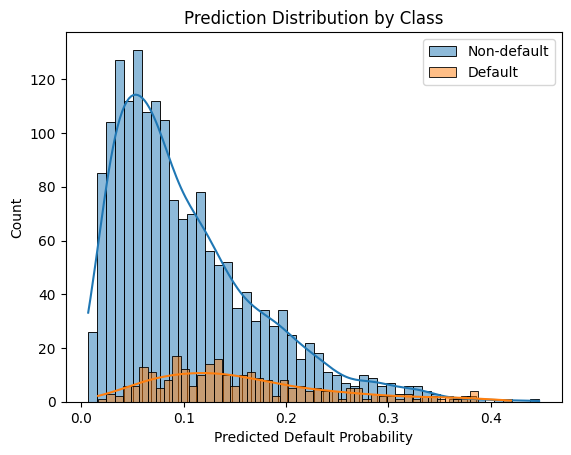

In [17]:
import seaborn as sns

sns.histplot(test_probs[y_test==0], label="Non-default", bins=50, kde=True)
sns.histplot(test_probs[y_test==1], label="Default", bins=50, kde=True)

plt.legend()
plt.xlabel("Predicted Default Probability")
plt.title("Prediction Distribution by Class")

plt.show()

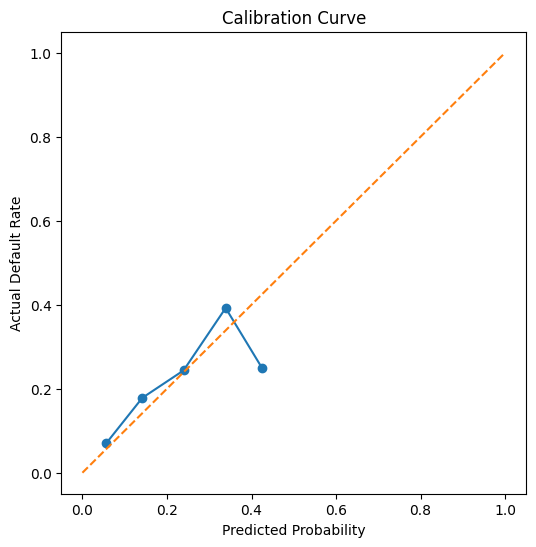

In [19]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Curve")

plt.show()

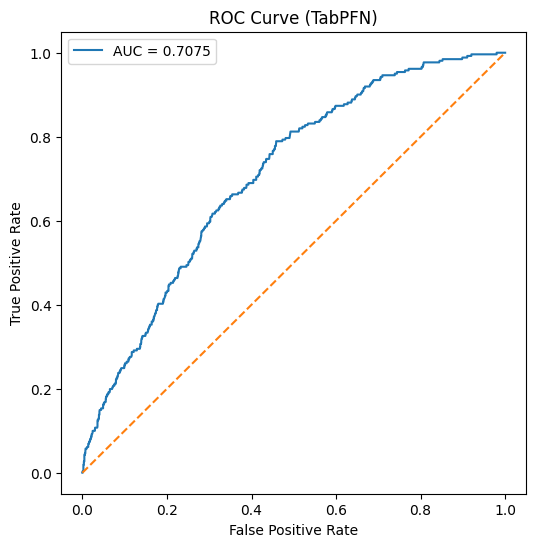

In [31]:
# compute ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, test_probs)

# compute AUC
auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (TabPFN)")
plt.legend()

plt.show()

# Fine Tuning

TabPFN allows additional performance improvements through fine-tuning and hyperparameter optimization. However, due to time constraints, extensive hyperparameter tuning was not explored in this project.

In [ ]:
finetuned_clf = FinetunedTabPFNClassifier(
    device="cuda",
    epochs=15,
    learning_rate=1e-5,
)

In [ ]:
finetuned_clf.fit(
    X_train,
    y_train,
    X_val=X_val,
    y_val=y_val
)

/usr/local/lib/python3.12/dist-packages/tabpfn/finetuning/finetuned_classifier.py:398: UserWarning: `output_dir` is not set. This means no checkpointing will be done and all progress will be lost if the training is interrupted.
  super().fit(X, y, X_val=X_val, y_val=y_val, output_dir=output_dir)


Finetuning Epoch 1/15:   0%|          | 0/1 [00:00<?, ?it/s]

Finetuning Epoch 2/15:   0%|          | 0/1 [00:00<?, ?it/s]

Finetuning Epoch 3/15:   0%|          | 0/1 [00:00<?, ?it/s]

Finetuning Epoch 4/15:   0%|          | 0/1 [00:00<?, ?it/s]

...

Finetuning Epoch 12/15:   0%|          | 0/1 [00:00<?, ?it/s]

Finetuning Epoch 13/15:   0%|          | 0/1 [00:00<?, ?it/s]

Finetuning Epoch 14/15:   0%|          | 0/1 [00:00<?, ?it/s]

Finetuning Epoch 15/15:   0%|          | 0/1 [00:00<?, ?it/s]

FinetunedTabPFNClassifier(epochs=15, eval_metric='roc_auc')

In [ ]:
tuned_val_probs = finetuned_clf.predict_proba(X_val)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

val_auc_tuned = roc_auc_score(y_val, tuned_val_probs)

print("Tuned Validation AUC:", val_auc_tuned)

Tuned Validation AUC: 0.7303942982742786


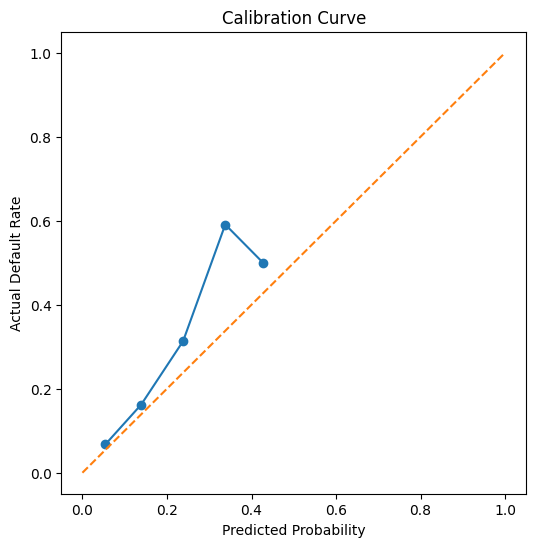

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_val, tuned_val_probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Curve")

plt.show()

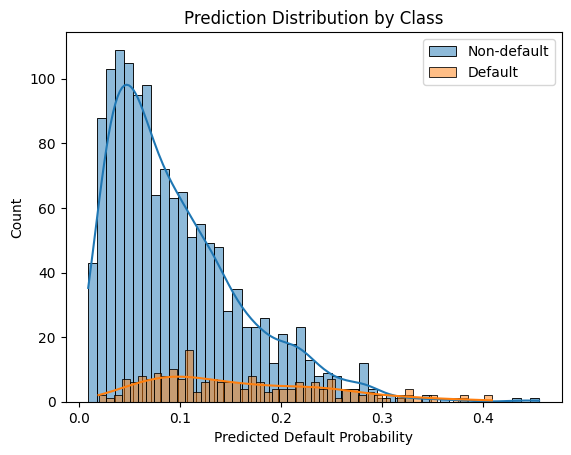

In [ ]:
import seaborn as sns

sns.histplot(tuned_val_probs[y_val==0], label="Non-default", bins=50, kde=True)
sns.histplot(tuned_val_probs[y_val==1], label="Default", bins=50, kde=True)

plt.legend()
plt.xlabel("Predicted Default Probability")
plt.title("Prediction Distribution by Class")

plt.show()

In [ ]:
tuned_test_probs = finetuned_clf.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, tuned_test_probs)
print(test_auc)

0.7074925255409482
